# House Price Prediction using Regression Models

**Name :** SRIJITH R

**Reg. no. :** 24MID0009

**Course code :** MDI3003

**Course Title :** Advanced Predictive Analytics 

**Faculty :** Dr. Durgesh Kumar

**Datasets Used :**
1. California Housing Dataset
2. Ames Housing Dataset

**Problem statement :**
House price predition is the important regression problem in ML.The objective of the LAB 01(House price prediction using Linear regression) is to predict house prices using the property features from the california dataset and ames dataset.Simple linear regression is to used to predict house prices using single feature whereas multiple linear regression is used to predict house prices using one or more features.The preformance of the both models are measured using performance metrices such as MSE,MAE,RMSE,R2 score.

**Objectives :** 1.) The objective is to learn a function that maps property attributes to a continuous price or price-per-unit-area target.
2.)The objective is to build a machine learning model that accurately predicts house prices based on these features. 


**Success Criteria :**


1. The model should achieve lower MAE and RMSE than the baseline model.
2. The model should generalize well without overfitting.
3. The residuals should not show any systematic pattern.
4. The prediction results should be meaningful for real-world use.
5.  The trained model should be reproducible and reusable.

**Step 1-Environment & impot libraries :**


In [1]:
import platform 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn
SEED = 42
np.random.seed(SEED)
print("Python:",platform.python_version())
print("pandas:",pd.__version__)
print("Scikit-learn:", sklearn.__version__)


Python: 3.14.0
pandas: 3.0.3
Scikit-learn: 1.9.0


**Step 2-Loading California Dataset**

In [2]:
# Option A: California Housing
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
c_df = housing.frame.rename(columns={'MedHouseVal': 'Price'}) 
print(housing.DESCR[:1000])
display(c_df.head())


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Step 2-Loading Ames dataset**

In [3]:
# Option C: Ames / Kaggle House Prices
# Download the CSV using the official course instructions and keep raw data unchanged. 
a_df = pd.read_csv(r'C:\Users\sriji\Downloads\ameshousing.csv')
display(a_df.head()) 
print(a_df.shape)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


(2930, 82)


**Step 3-Data audit for Ames hosuing dataset**

In [4]:
target_a='SalePrice' # replace for the selected dataset
print('Shape:', a_df.shape)
print('Target dtype:',a_df[target_a].dtype) 
display(a_df.head())
display(a_df.sample(min(5, len(a_df)),random_state=SEED))

audit = pd.DataFrame({ 'dtype': a_df.dtypes.astype(str),'missing_n': a_df.isna().sum(),
'missing_pct': 100 * a_df.isna().mean(),'unique_n': a_df.nunique(dropna=False)
}).sort_values('missing_pct',ascending=False)
display(audit.head(20))
print('Duplicate rows:',a_df.duplicated().sum()) 
print(a_df[target_a].describe())


Shape: (2930, 82)
Target dtype: int64


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1357,1358,903427090,70,RM,NaN,5100,Pave,Grvl,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2008,WD,Normal,161000
2367,2368,527450460,160,RM,21.0,1890,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,116000
2822,2823,908128100,60,RL,62.0,7162,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,196500
2126,2127,907135180,20,RL,60.0,8070,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,123600
1544,1545,910200080,30,RM,50.0,7000,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,7,2008,WD,Normal,126000


,dtype,missing_n,missing_pct,unique_n
Pool QC,str,2917,99.556314,5
Misc Feature,str,2824,96.382253,6
Alley,str,2732,93.242321,3
Fence,str,2358,80.477816,5
Mas Vnr Type,str,1775,60.580205,5
Fireplace Qu,str,1422,48.532423,6
Lot Frontage,float64,490,16.723549,129
Garage Qual,str,159,5.426621,6
Garage Yr Blt,float64,159,5.426621,104
Garage Cond,str,159,5.426621,6


Duplicate rows: 0
count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


**Step 3-Data audit California House pricing dataset**

In [5]:
target_c= 'Price' # replace for the selected dataset

print('Shape:', c_df.shape)
print('Target dtype:',c_df[target_c].dtype) 
display(c_df.head())
display(c_df.sample(min(5, len(c_df)),random_state=SEED))

audit = pd.DataFrame({ 'dtype': c_df.dtypes.astype(str),'missing_n': c_df.isna().sum(),
'missing_pct': 100 * c_df.isna().mean(),'unique_n': c_df.nunique(dropna=False)
}).sort_values('missing_pct',ascending=False)
display(audit.head(20))
print('Duplicate rows:',c_df.duplicated().sum()) 
print(c_df[target_c].describe())


Shape: (20640, 9)
Target dtype: float64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


,dtype,missing_n,missing_pct,unique_n
MedInc,float64,0,0.0,12928
HouseAge,float64,0,0.0,52
AveRooms,float64,0,0.0,19392
AveBedrms,float64,0,0.0,14233
Population,float64,0,0.0,3888
AveOccup,float64,0,0.0,18841
Latitude,float64,0,0.0,862
Longitude,float64,0,0.0,844
Price,float64,0,0.0,3842


Duplicate rows: 0
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: Price, dtype: float64


**Step 4-Calfornia housing house hold split**

In [6]:
from sklearn.model_selection import train_test_split
DROP_COLS = ['Id'] if 'Id' in c_df.columns else [] 
X = c_df.drop(columns=[target_c] + DROP_COLS) 
y = c_df[target_c].copy()
X_train_c,X_test_c,y_train_c,y_test_c=train_test_split(X,y,test_size=0.20,random_state=SEED)
print(X_train_c.shape,X_test_c.shape) 
print(y_train_c.shape,y_test_c.shape)


(16512, 8) (4128, 8)
(16512,) (4128,)


**Step 4-Ames hosuing dataset house hold split**

In [7]:
from sklearn.model_selection import train_test_split
target='SalePrice'
DROP_COLS = ['Id'] if 'Id' in a_df.columns else [] 
X = a_df.drop(columns=[target_a] + DROP_COLS) 
y = a_df[target_a].copy()
X_train_a,X_test_a,y_train_a,y_test_a=train_test_split(X,y,test_size=0.20,random_state=SEED)
print(X_train_a.shape,X_test_a.shape) 
print(y_train_a.shape,y_test_a.shape)

(2344, 81) (586, 81)
(2344,) (586,)


**Step 5-EDA(california dataset)**

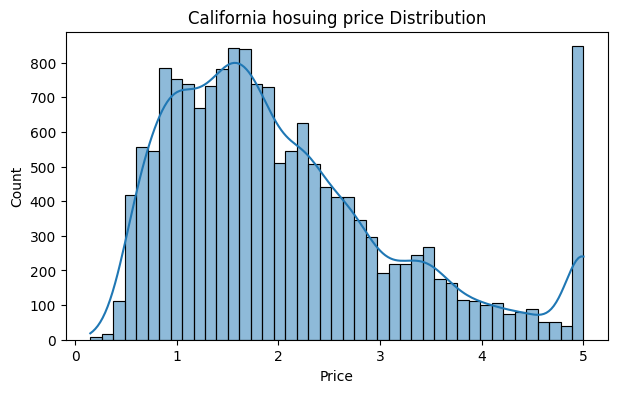

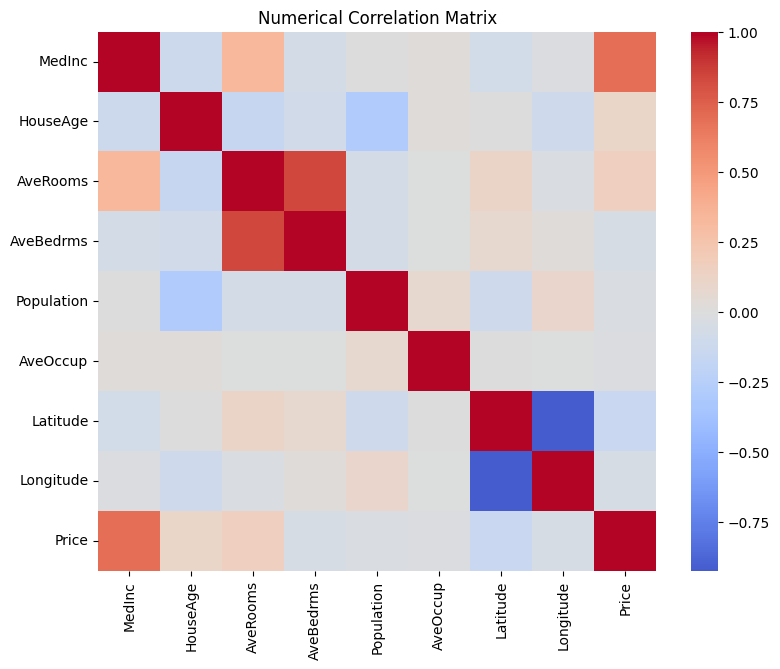

In [8]:
train_df = X_train_c.copy() 
train_df['Price'] = y_train_c
# Target distribution
fig, ax = plt.subplots(figsize=(7, 4)) 
sns.histplot(train_df['Price'], kde=True, ax=ax) 
ax.set_title('California hosuing price Distribution')
plt.show()
# Numerical correlations
num_df = train_df.select_dtypes(include=np.number) 
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0, ax=ax) 
ax.set_title('Numerical Correlation Matrix')
plt.show()


**Step 5-EDA(Ames dataset)**

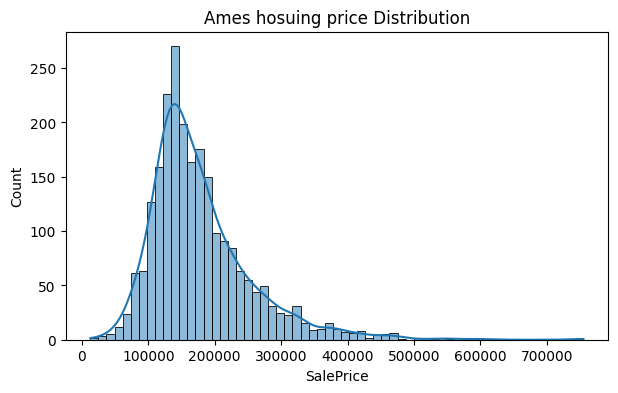

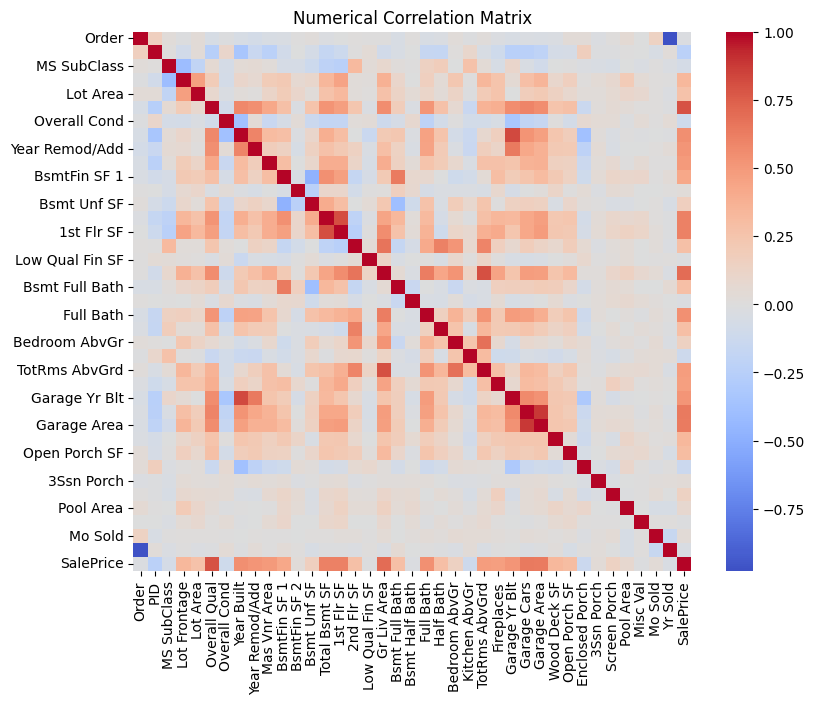

In [9]:
train_df = X_train_a.copy() 
train_df['SalePrice'] = y_train_a
# Target distribution
fig, ax = plt.subplots(figsize=(7, 4)) 
sns.histplot(train_df['SalePrice'], kde=True, ax=ax) 
ax.set_title('Ames hosuing price Distribution')
plt.show()
# Numerical correlations
num_df = train_df.select_dtypes(include=np.number) 
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0, ax=ax) 
ax.set_title('Numerical Correlation Matrix')
plt.show()


**Step 6-Build a leakage-safe preprocessing pipeline(california dataset)**

In [10]:
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
numeric_features_c = X_train_c.select_dtypes(include=np.number).columns.tolist()
categorical_features_c = X_train_c.select_dtypes(exclude=np.number).columns.tolist()
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocess_c = ColumnTransformer([('num', numeric_pipe, numeric_features_c),('cat', categorical_pipe, categorical_features_c)])

**Step 6-Build a leakage-safe preprocessing pipeline(ames dataset)**

In [11]:
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
numeric_features_a = X_train_a.select_dtypes(include=np.number).columns.tolist()
categorical_features_a = X_train_a.select_dtypes(exclude=np.number).columns.tolist()
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocess_a = ColumnTransformer([('num', numeric_pipe, numeric_features_a),('cat', categorical_pipe, categorical_features_a)])

**Step 7-Establish a naive baseline(California Datset)**

In [12]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
naive = DummyRegressor(strategy='mean') 
naive.fit(X_train_c[numeric_features_c], y_train_c) 
naive_pred = naive.predict(X_test_c[numeric_features_c])
print('Naive MAE:',mean_absolute_error(y_test_c, naive_pred)) 
print('Naive RMSE:',np.sqrt(mean_squared_error(y_test_c, naive_pred)))


Naive MAE: 0.9060685490007149
Naive RMSE: 1.1448563543099792


**Step 7-Establish a naive baseline(Ames Dataset)**

In [13]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
naive = DummyRegressor(strategy='mean') 
naive.fit(X_train_a[numeric_features_a],y_train_a) 
naive_pred = naive.predict(X_test_a[numeric_features_a])
print('Naive MAE:',mean_absolute_error(y_test_a,naive_pred)) 
print('Naive RMSE:',np.sqrt(mean_squared_error(y_test_a, naive_pred)))


Naive MAE: 64611.411613705466
Naive RMSE: 90222.37239996913


**Step 8-Simple Linear regression(CALIFORNIA DATASET)**

In [14]:
from sklearn.linear_model import LinearRegression
simple_feature_c = 'MedInc' # replace for the dataset 
simple_model_c = LinearRegression() 
simple_model_c.fit(X_train_c[[simple_feature_c]], y_train_c)
simple_pred_c = simple_model_c.predict(X_test_c[[simple_feature_c]])
print('Intercept:', simple_model_c.intercept_) 
print('Slope:', simple_model_c.coef_[0])


Intercept: 0.44459729169078677
Slope: 0.4193384939381274


**Step 8-Simple Linear regression(AMES DATASET)**

In [15]:
from sklearn.linear_model import LinearRegression
simple_feature_a = 'Gr Liv Area' # replace for the dataset 
simple_model_a = LinearRegression() 
simple_model_a.fit(X_train_a[[simple_feature_a]], y_train_a)
simple_pred_a = simple_model_a.predict(X_test_a[[simple_feature_a]])
print('Intercept:', simple_model_a.intercept_) 
print('Slope:', simple_model_a.coef_[0])


Intercept: 19250.559555372573
Slope: 106.72915508271505


**Step 9-Mulitple linear regression(california dataset)**

In [16]:
linear_pipeline_c = Pipeline([("preprocess",preprocess_c),("model",LinearRegression())])
linear_pipeline_c.fit(X_train_c, y_train_c)
linear_pred_c = linear_pipeline_c.predict(X_test_c)

**Step 9-Mulitple linear regression(ames dataset)**

In [17]:
linear_pipeline_a = Pipeline([("preprocess",preprocess_a),("model",LinearRegression())])
linear_pipeline_a.fit(X_train_a, y_train_a)
linear_pred_a = linear_pipeline_a.predict(X_test_a)

**Step 10-reusable evaluation function**


In [18]:
def evaluate_regressor(name,fitted_model,X_eval,y_eval):
    pred = fitted_model.predict(X_eval)
    mae = mean_absolute_error(y_eval, pred)
    mse = mean_squared_error(y_eval, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_eval, pred)
    Xt = fitted_model.named_steps["preprocess"].transform(X_eval)
    n,p = Xt.shape
    adj_r2 = np.nan if n <= p + 1 else 1 - (1-r2)*(n-1)/(n-p-1)
    return {
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted R2': adj_r2
    }, pred

**Step 10-COmparing regression models such as(Linear regression,Ridge,Elastic net,Random forest,Gradient Boosting) for the California Housing Dataset**

In [19]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
model_specs_c = {
    'Linear Regression':LinearRegression(),
    'Ridge':Ridge(alpha=1.0),
    'Elastic Net':ElasticNet(alpha=0.001,l1_ratio=0.5,max_iter=20000),
    'Random Forest':RandomForestRegressor(n_estimators=300,min_samples_leaf=2,random_state=SEED,n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=SEED)
}
fitted_models_c = {}
results_c = []
predictions_c = {}
for name, estimator in model_specs_c.items():
    pipe = Pipeline([('preprocess', preprocess_c),('model',estimator)])
    pipe.fit(X_train_c,y_train_c)
    row,pred = evaluate_regressor(name, pipe,X_test_c,y_test_c)
    results_c.append(row)
    fitted_models_c[name] =pipe
    predictions_c[name] =pred
results_df_c = pd.DataFrame(results_c).sort_values('RMSE')
display(results_df_c)

,Model,MAE,MSE,RMSE,R2,Adjusted R2
3,Random Forest,0.326278,0.253763,0.503749,0.806348,0.805972
4,Gradient Boosting,0.371650,0.293999,0.542217,0.775643,0.775208
2,Elastic Net,0.533123,0.554902,0.744917,0.576543,0.575721
1,Ridge,0.533193,0.555855,0.745557,0.575816,0.574992
0,Linear Regression,0.533200,0.555892,0.745581,0.575788,0.574964


**Step 10-COmparing regression models such as(Linear regression,Ridge,Elastic net,Random forest,Gradient Boosting) for the Ames Housing Dataset**

In [20]:
model_specs_a = {
    'Linear Regression':LinearRegression(),
    'Ridge':Ridge(alpha=1.0),
    'Elastic Net':ElasticNet(alpha=0.001,l1_ratio=0.5,max_iter=20000),
    'Random Forest':RandomForestRegressor(n_estimators=300,min_samples_leaf=2,random_state=SEED,n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=SEED)
}
fitted_models_a = {}
results_a = []
predictions_a = {}
for name,estimator in model_specs_a.items():
    pipe = Pipeline([('preprocess', preprocess_a),('model',estimator)])
    pipe.fit(X_train_a,y_train_a)
    row,pred = evaluate_regressor(name, pipe,X_test_a,y_test_a)
    results_a.append(row)
    fitted_models_a[name] =pipe
    predictions_a[name] =pred
results_df_a = pd.DataFrame(results_a).sort_values('RMSE')
display(results_df_a)

,Model,MAE,MSE,RMSE,R2,Adjusted R2
4,Gradient Boosting,15188.839985,6.434948e+08,25367.199995,0.919739,0.834090
3,Random Forest,15843.061355,7.212788e+08,26856.633942,0.910037,0.814035
1,Ridge,16192.352278,8.351273e+08,28898.568483,0.895838,0.784682
2,Elastic Net,16249.901357,8.366261e+08,28924.489648,0.895651,0.784295
0,Linear Regression,16034.553285,8.783380e+08,29636.767116,0.890448,0.773541


**Step 12-Polynomial Regression(California dataset)**

In [21]:
from sklearn.preprocessing import PolynomialFeatures
selected_numeric_c = ['MedInc','HouseAge','AveRooms']
poly_pipe_c = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('poly',PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler',StandardScaler()),
    ('model',Ridge(alpha=1.0))
])
poly_pipe_c.fit(X_train_c[selected_numeric_c],y_train_c)
poly_pred_c = poly_pipe_c.predict(X_test_c[selected_numeric_c])

**Step 12-Polynomial regression(Ames dataset)**

In [22]:
selected_numeric_a = ['Gr Liv Area','Overall Qual','Year Built']
poly_pipe_a = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])
poly_pipe_a.fit(X_train_a[selected_numeric_a],y_train_a)
poly_pred_a = poly_pipe_a.predict(X_test_a[selected_numeric_a])


**Step 13-Cross-validation(California dataset)**

In [23]:
from sklearn.model_selection import KFold, cross_validate
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'mae':'neg_mean_absolute_error','rmse':'neg_root_mean_squared_error','r2':'r2'}
cv_rows = []
for name,estimator in model_specs_c.items():
    pipe = Pipeline([('preprocess', preprocess_c),('model', estimator)])
    scores = cross_validate(pipe,X_train_c,y_train_c,cv=cv,scoring=scoring,n_jobs=-1)
    cv_rows.append({'Model': name,'Key parameters':estimator.get_params(),'CV MAE mean':-scores['test_mae'].mean(),'CV RMSE mean':-scores['test_rmse'].mean(),'CV RMSE SD': scores['test_rmse'].std(),'CV R² mean':scores['test_r2'].mean(),'Fit time':scores['fit_time'].mean()})
cv_results_c = pd.DataFrame(cv_rows).sort_values('CV RMSE mean')
display(cv_results_c)

,Model,Key parameters,CV MAE mean,CV RMSE mean,CV RMSE SD,CV R² mean,Fit time
3,Random Forest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",0.333100,0.509570,0.011508,0.805684,30.196898
4,Gradient Boosting,"{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': ...",0.369770,0.532115,0.011541,0.788103,7.934558
2,Elastic Net,"{'alpha': 0.001, 'copy_X': True, 'fit_intercep...",0.529060,0.720507,0.013875,0.611460,0.097141
1,Ridge,"{'alpha': 1.0, 'copy_X': True, 'fit_intercept'...",0.529056,0.720509,0.013895,0.611457,0.147001
0,Linear Regression,"{'copy_X': True, 'fit_intercept': True, 'n_job...",0.529061,0.720510,0.013895,0.611457,0.154762


**Step 13-Cross-validation(Ames dataset)**

In [24]:
cv = KFold(n_splits=5,shuffle=True,random_state=SEED)
scoring = {'mae':'neg_mean_absolute_error','rmse':'neg_root_mean_squared_error','r2':'r2'}
cv_rows = []
for name, estimator in model_specs_a.items():
    pipe = Pipeline([('preprocess', preprocess_a),('model',estimator)])
    scores = cross_validate(pipe,X_train_a,y_train_a,cv=cv,scoring=scoring,n_jobs=-1)
    cv_rows.append({'Model': name,'Key parameters':estimator.get_params(),'CV MAE mean':-scores['test_mae'].mean(),'CV RMSE mean':-scores['test_rmse'].mean(),'CV RMSE SD': scores['test_rmse'].std(),'CV R² mean':scores['test_r2'].mean(),'Fit time':scores['fit_time'].mean()})
cv_results_a = pd.DataFrame(cv_rows).sort_values('CV RMSE mean')
display(cv_results_a)

,Model,Key parameters,CV MAE mean,CV RMSE mean,CV RMSE SD,CV R² mean,Fit time
4,Gradient Boosting,"{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': ...",15047.257727,24598.198669,6784.755369,0.890384,6.208408
3,Random Forest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",16165.842605,26590.901420,5764.135982,0.875502,19.916882
0,Linear Regression,"{'copy_X': True, 'fit_intercept': True, 'n_job...",16438.498746,28208.668924,9519.268807,0.851311,0.352140
2,Elastic Net,"{'alpha': 0.001, 'copy_X': True, 'fit_intercep...",16576.642306,29048.393526,9014.043203,0.844746,19.634737
1,Ridge,"{'alpha': 1.0, 'copy_X': True, 'fit_intercept'...",16583.575569,29067.542460,9010.536129,0.844574,0.254651


**Step 14-Ridge hyperparameter tuning(california dataset)**

In [25]:
from sklearn.model_selection import GridSearchCV
ridge_pipe_c = Pipeline([
    ('preprocess',preprocess_c),
    ('model',Ridge())
])
ridge_grid = {
    'model__alpha':np.logspace(-3, 3, 13)
}
search_c = GridSearchCV(
    ridge_pipe_c,
    param_grid=ridge_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)
search_c.fit(X_train_c,y_train_c)
print('Best Parameters:',search_c.best_params_)
print('Best CV RMSE:',-search_c.best_score_)
best_ridge_c = search_c.best_estimator_

Best Parameters: {'model__alpha': np.float64(3.1622776601683795)}
Best CV RMSE: 0.7205088107791665


**Step 14-Ridge hyperparameter tuning(Ames dataset)**

In [26]:
from sklearn.model_selection import GridSearchCV
ridge_pipe_a = Pipeline([
    ('preprocess',preprocess_a),
    ('model',Ridge())
])
ridge_grid = {
    'model__alpha':np.logspace(-3, 3, 13)
}
search_a = GridSearchCV(
    ridge_pipe_a,
    param_grid=ridge_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)
search_a.fit(X_train_a,y_train_a)
print('Best Parameters:',search_a.best_params_)
print('Best CV RMSE:',-search_a.best_score_)
best_ridge_a = search_a.best_estimator_

Best Parameters: {'model__alpha': np.float64(0.03162277660168379)}
Best CV RMSE: 28181.48493914451


**Step 15-Diagnose overfitting and underfitting -- Train-test performance gap fr the california datset**

In [27]:
def split_metrics(model, X_train, y_train, X_test, y_test):
    rows = []
    for split_name,Xs,ys in[ ('Train',X_train,y_train),('Test',X_test,y_test)]:
        pred = model.predict(Xs) 
        rows.append({'Split':split_name,'MAE':mean_absolute_error(ys, pred),'RMSE':np.sqrt(mean_squared_error(ys, pred)),'R2': r2_score(ys, pred)})
    return pd.DataFrame(rows)
for name in ['Linear Regression', 'Gradient Boosting', 'Ridge', 'Random Forest']:
    print(name)
    display(split_metrics(fitted_models_c[name],X_train_c,y_train_c,X_test_c,y_test_c))


Linear Regression


,Split,MAE,RMSE,R2
0,Train,0.528628,0.719676,0.612551
1,Test,0.533200,0.745581,0.575788


Gradient Boosting


,Split,MAE,RMSE,R2
0,Train,0.356633,0.510694,0.804898
1,Test,0.371650,0.542217,0.775643


Ridge


,Split,MAE,RMSE,R2
0,Train,0.528624,0.719676,0.612551
1,Test,0.533193,0.745557,0.575816


Random Forest


,Split,MAE,RMSE,R2
0,Train,0.143641,0.233814,0.959104
1,Test,0.326278,0.503749,0.806348


**Step 15-Diagnose overfitting and underfitting -- Train-test performance gap fr the ames datset**

In [28]:
def split_metrics(model, X_train, y_train, X_test, y_test):
    rows = []
    for split_name,Xs,ys in[ ('Train',X_train,y_train),('Test',X_test,y_test)]:
        pred = model.predict(Xs) 
        rows.append({'Split':split_name,'MAE':mean_absolute_error(ys, pred),'RMSE':np.sqrt(mean_squared_error(ys, pred)),'R2': r2_score(ys, pred)})
    return pd.DataFrame(rows)
for name in ['Linear Regression', 'Gradient Boosting','Ridge','Random Forest']:
    print(name)
    display(split_metrics(fitted_models_a[name],X_train_a,y_train_a,X_test_a,y_test_a))


Linear Regression


,Split,MAE,RMSE,R2
0,Train,13130.726754,18972.637838,0.939459
1,Test,16034.553285,29636.767116,0.890448


Gradient Boosting


,Split,MAE,RMSE,R2
0,Train,11220.438808,15255.160451,0.960859
1,Test,15188.839985,25367.199995,0.919739


Ridge


,Split,MAE,RMSE,R2
0,Train,13734.112933,20464.226622,0.929566
1,Test,16192.352278,28898.568483,0.895838


Random Forest


,Split,MAE,RMSE,R2
0,Train,6465.570059,11768.405801,0.976707
1,Test,15843.061355,26856.633942,0.910037


**Step 16-Performing residual analysis fr the california dataset**

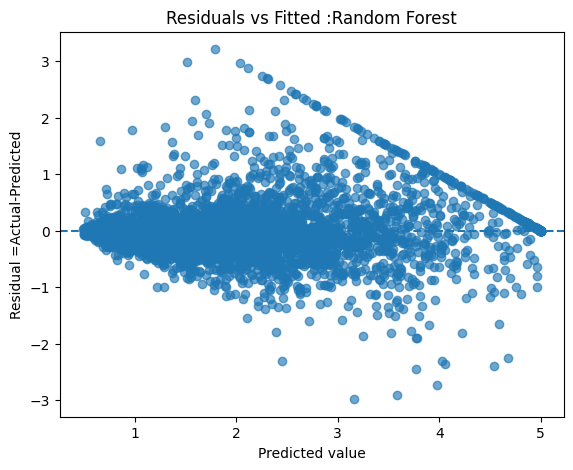

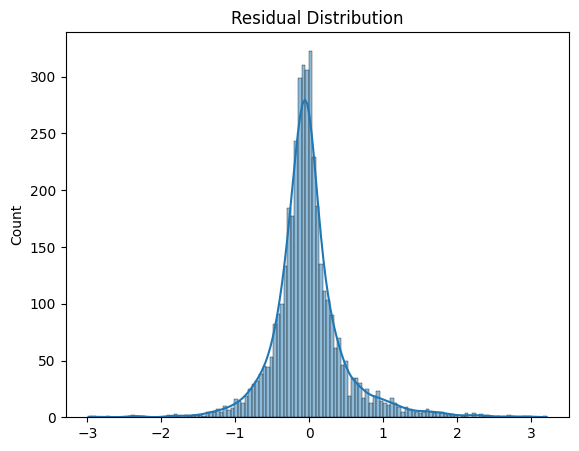

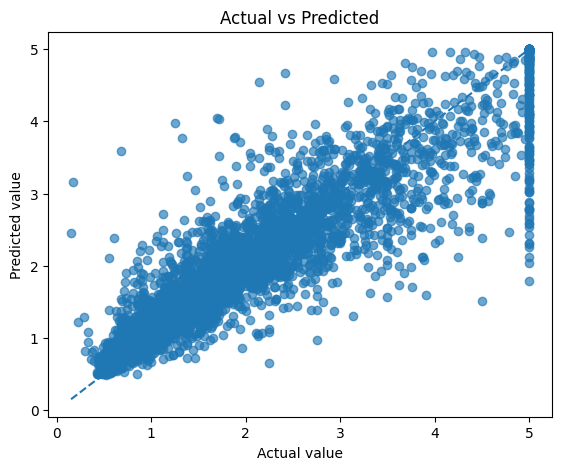

In [29]:
selected_name_c =results_df_c.iloc[0]['Model']
y_pred_c =predictions_c[selected_name_c]
residuals_c = y_test_c.to_numpy()-y_pred_c
fig, ax = plt.subplots(figsize=(6.5,5))
ax.scatter(y_pred_c, residuals_c,alpha=0.65)
ax.axhline(0, linestyle='--')
ax.set_xlabel('Predicted value')
ax.set_ylabel('Residual =Actual-Predicted')
ax.set_title(f'Residuals vs Fitted :{selected_name_c}')
plt.show()
fig, ax = plt.subplots(figsize=(6.5,5))
sns.histplot(residuals_c,kde=True,ax=ax)
ax.set_title('Residual Distribution')
plt.show()
fig, ax = plt.subplots(figsize=(6.5,5))
ax.scatter(y_test_c, y_pred_c,alpha=0.65)
lo = min(y_test_c.min(),y_pred_c.min())
hi = max(y_test_c.max(),y_pred_c.max())
ax.plot([lo, hi],[lo, hi],linestyle='--')
ax.set_xlabel('Actual value')
ax.set_ylabel('Predicted value')
ax.set_title('Actual vs Predicted')
plt.show()

**Step 16-Performing residual analysis fr the ames dataset**

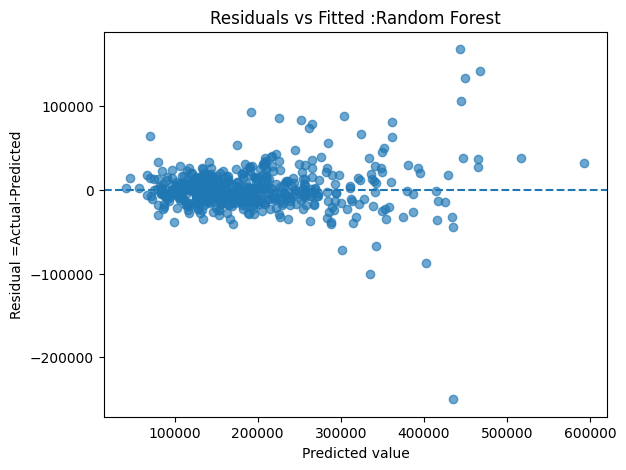

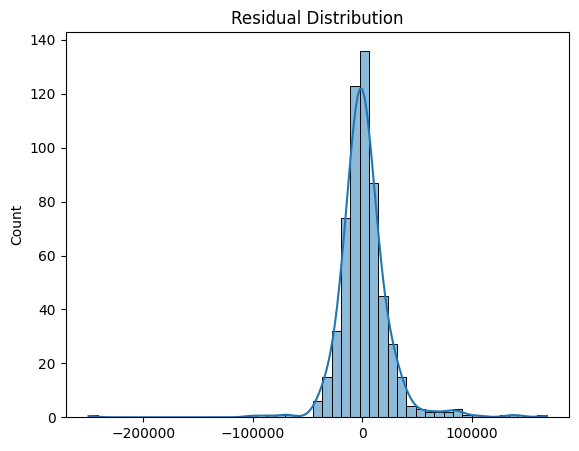

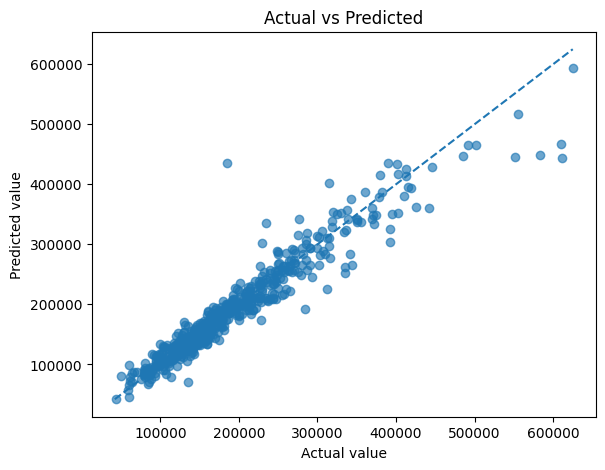

In [30]:
selected_name_a =results_df_a.iloc[0]['Model']
y_pred_a =predictions_a[selected_name_a]
residuals_a = y_test_a.to_numpy()-y_pred_a
fig,ax = plt.subplots(figsize=(6.5,5))
ax.scatter(y_pred_a,residuals_a,alpha=0.65)
ax.axhline(0,linestyle='--')
ax.set_xlabel('Predicted value')
ax.set_ylabel('Residual =Actual-Predicted')
ax.set_title(f'Residuals vs Fitted :{selected_name_c}')
plt.show()
fig,ax = plt.subplots(figsize=(6.5,5))
sns.histplot(residuals_a,kde=True,ax=ax)
ax.set_title('Residual Distribution')
plt.show()
fig,ax = plt.subplots(figsize=(6.5,5))
ax.scatter(y_test_a,y_pred_a,alpha=0.65)
lo = min(y_test_a.min(),y_pred_a.min())
hi = max(y_test_a.max(),y_pred_a.max())
ax.plot([lo, hi],[lo, hi],linestyle='--')
ax.set_xlabel('Actual value')
ax.set_ylabel('Predicted value')
ax.set_title('Actual vs Predicted')
plt.show()

**Step 17-Inspect linear coefficients - Coefficient table(califronia dataset)**

In [31]:
linear_fitted_c=fitted_models_c['Linear Regression']
feature_names_c=linear_fitted_c.named_steps['preprocess'].get_feature_names_out()
coefficients_c=linear_fitted_c.named_steps['model'].coef_
coef_df_c=pd.DataFrame({
    'Feature':feature_names_c,
    'Coefficient':coefficients_c,
    'AbsCoefficient':np.abs(coefficients_c)
}).sort_values('AbsCoefficient',ascending=False)
display(coef_df_c.head(20))

,Feature,Coefficient,AbsCoefficient
6,num__Latitude,-0.896929,0.896929
7,num__Longitude,-0.869842,0.869842
0,num__MedInc,0.854383,0.854383
3,num__AveBedrms,0.339259,0.339259
2,num__AveRooms,-0.294410,0.294410
1,num__HouseAge,0.122546,0.122546
5,num__AveOccup,-0.040829,0.040829
4,num__Population,-0.002308,0.002308


**Step 17-Inspect linear coefficients - Coefficient table(ames dataset)**

In [32]:
linear_fitted_a=fitted_models_a['Linear Regression']
feature_names_a=linear_fitted_a.named_steps['preprocess'].get_feature_names_out()
coefficients_a=linear_fitted_a.named_steps['model'].coef_
coef_df_a=pd.DataFrame({
    'Feature':feature_names_a,
    'Coefficient':coefficients_a,
    'AbsCoefficient':np.abs(coefficients_a)
}).sort_values('AbsCoefficient',ascending=False)
display(coef_df_a.head(20))

,Feature,Coefficient,AbsCoefficient
132,cat__Roof Matl_ClyTile,-579668.891805,579668.891805
282,cat__Misc Feature_Elev,-409410.081386,409410.081386
284,cat__Misc Feature_Othr,152077.428859,152077.428859
10,num__BsmtFin SF 1,145263.140467,145263.140467
12,num__Bsmt Unf SF,130461.955741,130461.955741
285,cat__Misc Feature_Shed,128778.701569,128778.701569
283,cat__Misc Feature_Gar2,128553.950958,128553.950958
134,cat__Roof Matl_Membran,125572.868896,125572.868896
13,num__Total Bsmt SF,-122517.480893,122517.480893
139,cat__Roof Matl_WdShngl,110233.323799,110233.323799


**Step 20-Saving the selected pipeline and evidence(California dataset)**

In [33]:
import json
import joblib
final_model_c=best_ridge_c
joblib.dump(final_model_c,'24MID0009_Lab01_california_Model.joblib')
results_df_c.to_csv('california_model_comparison.csv',index=False)
cv_results_c.to_csv('24MID0009_Lab01_california_results.csv', index=False)
run_metadata_c = {
    'random_seed':SEED,
    'target':target_c,
    'train_rows':len(X_train_c),
    'test_rows':len(X_test_c),
    'selected_model':'Tuned Ridge Regression'
}
with open('california_metadata.json','w') as f:
    json.dump(run_metadata_c,f,indent=2)

**Step 20-Saving the selected pipeline and evidence(Ames dataset)**

In [34]:
import json
import joblib
final_model_a=best_ridge_a
joblib.dump(final_model_a,'24MID0009_Lab01_ames_Model.joblib')
results_df_a.to_csv('ames_model_comparison.csv',index=False)
cv_results_a.to_csv('24MID0009_Lab01_ames_results.csv', index=False)
run_metadata_a = {
    'random_seed':SEED,
    'target':target_a,
    'train_rows':len(X_train_a),
    'test_rows':len(X_test_a),
    'selected_model':'Tuned Ridge Regression'
}
with open('ames_metadata.json','w') as f:
    json.dump(run_metadata_c,f,indent=2)

In [35]:
display(results_df_c)

,Model,MAE,MSE,RMSE,R2,Adjusted R2
3,Random Forest,0.326278,0.253763,0.503749,0.806348,0.805972
4,Gradient Boosting,0.371650,0.293999,0.542217,0.775643,0.775208
2,Elastic Net,0.533123,0.554902,0.744917,0.576543,0.575721
1,Ridge,0.533193,0.555855,0.745557,0.575816,0.574992
0,Linear Regression,0.533200,0.555892,0.745581,0.575788,0.574964


In [36]:
display(results_df_a)

,Model,MAE,MSE,RMSE,R2,Adjusted R2
4,Gradient Boosting,15188.839985,6.434948e+08,25367.199995,0.919739,0.834090
3,Random Forest,15843.061355,7.212788e+08,26856.633942,0.910037,0.814035
1,Ridge,16192.352278,8.351273e+08,28898.568483,0.895838,0.784682
2,Elastic Net,16249.901357,8.366261e+08,28924.489648,0.895651,0.784295
0,Linear Regression,16034.553285,8.783380e+08,29636.767116,0.890448,0.773541


**Final Summary**
1. Built regression models for the California Housing and Ames Housing datasets
2. Compared Linear Regression,Ridge,Elastic Net,Random Forest and the Gradient Boosting
3. On comparing,Gradient Boosting and Random Forest achieved the best prediction performance
4. Hyperparameter tuning using Grid Search(GridSearchCV) improved the Ridge model
5. Cross validation confirmed that the selected models generalize well

**Limitations**

1. Performance depends on the quality and completeness of the datasets that we are taking
2. Extreme house prices may still produce larger prediction errors 
3. Only regression algorithms included in this lab were evaluated
4. Additional feature engineering and more data could further improve performance